In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import paho.mqtt.client as mqtt
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully")

 All libraries imported successfully


In [16]:
# Load sensor data from CSV exported from InfluxDB
csv_path = r'c:\Users\Emadr\Desktop\Iot_Server\CollecteData.csv'

# Skip InfluxDB metadata rows (first 3 lines contain headers and datatypes)
df = pd.read_csv(csv_path, skiprows=3)

# Display data info
print(f" Dataset Shape: {df.shape}")
print(f"\n Column Names:\n{df.columns.tolist()}")
print(f"\n Data Types:\n{df.dtypes}")
print(f"\n Data Sample:\n{df.head(10)}")

# Extract sensor topics based on NodeMCU publishing
# Topics: medical/test/bpm, medical/test/spo2, medical/test/temp, copilot/data/esp8266/rssi
bpm_data = df[df['topic'] == 'medical/test/bpm'].copy()
spo2_data = df[df['topic'] == 'medical/test/spo2'].copy()
temp_data = df[df['topic'] == 'medical/test/temp'].copy()

print(f"\n BPM readings (MAX30100): {len(bpm_data)}")
print(f" SpO2 readings (MAX30100): {len(spo2_data)}")
print(f"Temperature readings: {len(temp_data)}")

# Display statistics for validation thresholds
print(f"\n BPM Statistics:")
print(f"   Min: {bpm_data['_value'].min():.1f}, Max: {bpm_data['_value'].max():.1f}")
print(f"   Mean: {bpm_data['_value'].mean():.1f}, Std: {bpm_data['_value'].std():.1f}")

print(f"\n SpO2 Statistics:")
print(f"   Min: {spo2_data['_value'].min():.1f}, Max: {spo2_data['_value'].max():.1f}")
print(f"   Mean: {spo2_data['_value'].mean():.1f}, Std: {spo2_data['_value'].std():.1f}")

print(f"\n Temperature Statistics:")
print(f"   Min: {temp_data['_value'].min():.1f}, Max: {temp_data['_value'].max():.1f}")
print(f"   Mean: {temp_data['_value'].mean():.1f}, Std: {temp_data['_value'].std():.1f}")

 Dataset Shape: (26643, 10)

 Column Names:
['Unnamed: 0', 'result', 'table', '_start', '_stop', '_time', '_value', '_field', '_measurement', 'topic']

 Data Types:
Unnamed: 0      float64
result          float64
table             int64
_start           object
_stop            object
_time            object
_value          float64
_field           object
_measurement     object
topic            object
dtype: object

 Data Sample:
   Unnamed: 0  result  table                          _start  \
0         NaN     NaN      0  2025-12-27T18:09:16.221792234Z   
1         NaN     NaN      0  2025-12-27T18:09:16.221792234Z   
2         NaN     NaN      0  2025-12-27T18:09:16.221792234Z   
3         NaN     NaN      0  2025-12-27T18:09:16.221792234Z   
4         NaN     NaN      0  2025-12-27T18:09:16.221792234Z   
5         NaN     NaN      0  2025-12-27T18:09:16.221792234Z   
6         NaN     NaN      0  2025-12-27T18:09:16.221792234Z   
7         NaN     NaN      0  2025-12-27T18:09:16.2217

In [17]:
# Convert timestamp to datetime and sort
# Handle ISO8601 format with nanoseconds
df['_time'] = pd.to_datetime(df['_time'], format='ISO8601')
df = df.sort_values('_time').reset_index(drop=True)

# Separate by sensor type
bpm_data = df[df['topic'] == 'medical/test/bpm'].copy()
spo2_data = df[df['topic'] == 'medical/test/spo2'].copy()
temp_data = df[df['topic'] == 'medical/test/temp'].copy()

# Remove zero values (sensor errors or initialization)
bpm_clean = bpm_data[bpm_data['_value'] > 0].copy()
spo2_clean = spo2_data[spo2_data['_value'] > 0].copy()
temp_clean = temp_data[temp_data['_value'] > 0].copy()

print(f" Data Cleaning Results:")
print(f"   BPM: Removed {len(bpm_data) - len(bpm_clean)} zero values → {len(bpm_clean)} valid")
print(f"   SpO2: Removed {len(spo2_data) - len(spo2_clean)} zero values → {len(spo2_clean)} valid")
print(f"   Temp: Removed {len(temp_data) - len(temp_clean)} zero values → {len(temp_clean)} valid")

# Update data
bpm_data = bpm_clean
spo2_data = spo2_clean
temp_data = temp_clean

print(f"\n Dataset ready for validation model training")

 Data Cleaning Results:
   BPM: Removed 5290 zero values → 3670 valid
   SpO2: Removed 6028 zero values → 2924 valid
   Temp: Removed 0 zero values → 8731 valid

 Dataset ready for validation model training


In [18]:
# Function to label valid/invalid based on MAX30100 spike detection
def label_readings(features, sensor_type):
    """
    Label readings as valid (1) or invalid (0) based on MAX30100 sensor characteristics
    Invalid if: values outside physiologically valid range OR excessive spike between readings
    """
    labels = np.ones(len(features))
    
    if sensor_type == 'bpm':
        # Heart rate out of valid range (40-140 bpm)
        labels[(features['value'] < BPM_MIN) | (features['value'] > BPM_MAX)] = 0
        # Excessive spike (> 25 bpm change)
        labels[features['abs_change'] > BPM_SPIKE_THRESHOLD] = 0
    
    elif sensor_type == 'spo2':
        # SpO2 out of valid range (85-100%)
        labels[(features['value'] < SPO2_MIN) | (features['value'] > SPO2_MAX)] = 0
        # Excessive spike (> 8% change)
        labels[features['abs_change'] > SPO2_SPIKE_THRESHOLD] = 0
    
    elif sensor_type == 'temp':
        # Temperature out of valid range (36-39°C)
        labels[(features['value'] < TEMP_MIN) | (features['value'] > TEMP_MAX)] = 0
        # Excessive spike (> 1.5°C change)
        labels[features['abs_change'] > TEMP_SPIKE_THRESHOLD] = 0
    
    return labels

# Label all sensor types
bpm_features['label'] = label_readings(bpm_features, 'bpm')
spo2_features['label'] = label_readings(spo2_features, 'spo2')
temp_features['label'] = label_readings(temp_features, 'temp')

# Combine features for training
train_data = pd.concat([bpm_features, spo2_features, temp_features], ignore_index=True)

print(f" Training Dataset Size: {len(train_data)} total samples")
print(f"\n{'='*50}")
print(f" VALID readings: {(train_data['label'] == 1).sum()} ({(train_data['label'] == 1).sum()/len(train_data)*100:.1f}%)")
print(f" INVALID readings: {(train_data['label'] == 0).sum()} ({(train_data['label'] == 0).sum()/len(train_data)*100:.1f}%)")
print(f"{'='*50}")

print(f"\n BPM Breakdown:")
print(f"    Valid: {(bpm_features['label'] == 1).sum()}")
print(f"    Invalid: {(bpm_features['label'] == 0).sum()}")

print(f"\n SpO2 Breakdown:")
print(f"    Valid: {(spo2_features['label'] == 1).sum()}")
print(f"   Invalid: {(spo2_features['label'] == 0).sum()}")

print(f"\n Temperature Breakdown:")
print(f"    Valid: {(temp_features['label'] == 1).sum()}")
print(f"    Invalid: {(temp_features['label'] == 0).sum()}")

 Training Dataset Size: 15325 total samples

 VALID readings: 13095 (85.4%)
 INVALID readings: 2230 (14.6%)

 BPM Breakdown:
    Valid: 3223
    Invalid: 447

 SpO2 Breakdown:
    Valid: 2914
   Invalid: 10

 Temperature Breakdown:
    Valid: 6958
    Invalid: 1773


In [19]:
# Validation thresholds based on medical standards for MAX30100
# Reference: MAX30100 is designed for SpO2 (85-100%) and BPM (40-240 typical)

BPM_MIN = 40          # Minimum heart rate (severe bradycardia)
BPM_MAX = 140         # Maximum normal heart rate (with some wiggle room)
BPM_SPIKE_THRESHOLD = 25  # Max realistic change between 200ms readings

SPO2_MIN = 85         # Minimum SpO2 (hypoxemia alert)
SPO2_MAX = 100        # Maximum SpO2 (100% is realistic)
SPO2_SPIKE_THRESHOLD = 8  # Max realistic change between readings

TEMP_MIN = 36.0       # Minimum temperature (hypothermia)
TEMP_MAX = 39.0       # Maximum temperature (fever threshold)
TEMP_SPIKE_THRESHOLD = 1.5  # Max realistic change

# Function to create features for anomaly detection
def create_features(data, window=5):
    """Create features based on rolling statistics"""
    features = pd.DataFrame()
    features['value'] = data['_value'].values
    
    # Rolling statistics
    features['rolling_mean'] = data['_value'].rolling(window=window, min_periods=1).mean()
    features['rolling_std'] = data['_value'].rolling(window=window, min_periods=1).std()
    features['rolling_max'] = data['_value'].rolling(window=window, min_periods=1).max()
    features['rolling_min'] = data['_value'].rolling(window=window, min_periods=1).min()
    
    # Deviation from rolling mean
    features['deviation'] = abs(features['value'] - features['rolling_mean'])
    
    # Change between consecutive values
    features['change'] = data['_value'].diff().fillna(0)
    features['abs_change'] = abs(features['change'])
    
    # Fill NaN values
    features = features.fillna(0)
    
    return features

# Create features for each sensor type
bpm_features = create_features(bpm_data, window=5)
bpm_features['sensor'] = 'bpm'

spo2_features = create_features(spo2_data, window=5)
spo2_features['sensor'] = 'spo2'

temp_features = create_features(temp_data, window=5)
temp_features['sensor'] = 'temp'

print(f"\n Created features for BPM: {len(bpm_features)} samples")
print(f" Created features for SpO2: {len(spo2_features)} samples")
print(f" Created features for Temperature: {len(temp_features)} samples")
print(f"\n BPM Features Sample:\n{bpm_features.head()}")


 Created features for BPM: 3670 samples
 Created features for SpO2: 2924 samples
 Created features for Temperature: 8731 samples

 BPM Features Sample:
   value  rolling_mean  rolling_std  rolling_max  rolling_min  deviation  \
0   10.4           0.0          0.0          0.0          0.0        0.0   
1   46.5           0.0          0.0          0.0          0.0        0.0   
2   60.2           0.0          0.0          0.0          0.0        0.0   
3   72.3           0.0          0.0          0.0          0.0        0.0   
4   69.4           0.0          0.0          0.0          0.0        0.0   

   change  abs_change sensor  
0     0.0         0.0    bpm  
1     0.0         0.0    bpm  
2     0.0         0.0    bpm  
3     0.0         0.0    bpm  
4     0.0         0.0    bpm  


In [20]:
# Prepare training data for model
feature_cols = ['rolling_mean', 'rolling_std', 'rolling_max', 'rolling_min', 'deviation', 'abs_change']
X = train_data[feature_cols].values
y = train_data['label'].values

# Normalize features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Maintain class distribution
)

print(f"📚 Training Configuration:")
print(f"   Total samples: {len(X)}")
print(f"   Training set: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test set: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"   Features: {feature_cols}")

# Train Random Forest Classifier (uses spike labels)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'  # Handle class imbalance
)

rf_model.fit(X_train, y_train)

# Also train Isolation Forest for unsupervised anomaly detection
iso_forest = IsolationForest(
    contamination=0.15,  # Assume 15% anomalies
    random_state=42,
    n_estimators=100
)
iso_forest.fit(X_train)

print(f"\n Random Forest Classifier trained")
print(f" Isolation Forest trained")
print(f"\nModels ready for real-time sensor validation")

📚 Training Configuration:
   Total samples: 15325
   Training set: 12260 (80.0%)
   Test set: 3065 (20.0%)
   Features: ['rolling_mean', 'rolling_std', 'rolling_max', 'rolling_min', 'deviation', 'abs_change']

 Random Forest Classifier trained
 Isolation Forest trained

Models ready for real-time sensor validation


 RANDOM FOREST CLASSIFIER PERFORMANCE

 Accuracy:  0.9051
 Precision: 0.9151
 Recall:    0.9798
F1-Score:  0.9463

 Confusion Matrix (Random Forest):
[[ 208  238]
 [  53 2566]]

 Classification Report:
              precision    recall  f1-score   support

 Invalid (0)       0.80      0.47      0.59       446
   Valid (1)       0.92      0.98      0.95      2619

    accuracy                           0.91      3065
   macro avg       0.86      0.72      0.77      3065
weighted avg       0.90      0.91      0.89      3065



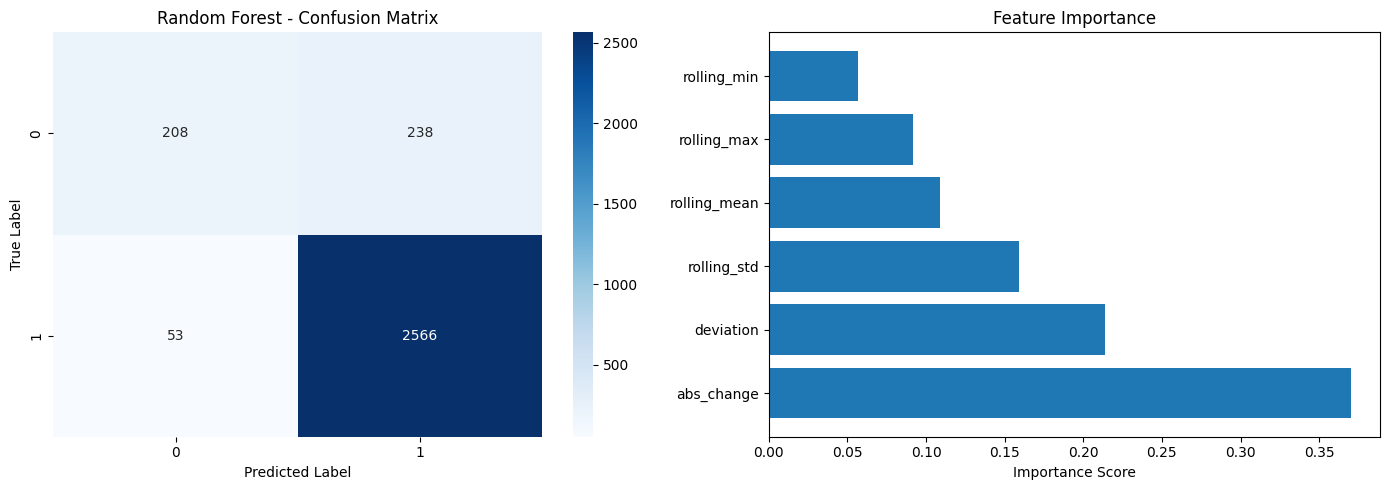


 Models evaluated and validated!


In [21]:
# Evaluate Random Forest (uses actual labels)
print("=" * 60)
print(" RANDOM FOREST CLASSIFIER PERFORMANCE")
print("=" * 60)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

print(f"\n Accuracy:  {accuracy_rf:.4f}")
print(f" Precision: {precision_rf:.4f}")
print(f" Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")

print(f"\n Confusion Matrix (Random Forest):")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

print(f"\n Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Invalid (0)', 'Valid (1)']))

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest CM
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest - Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

axes[1].barh(feature_importance['feature'], feature_importance['importance'])
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print(f"\n Models evaluated and validated!")

 MODEL PERFORMANCE - RANDOM FOREST CLASSIFIER

 Classification Metrics:
    Accuracy:  0.9051 (90.51%)
    Precision: 0.9151 (% of predicted invalid that are truly invalid)
    Recall:    0.9798 (% of actual invalid that are detected)
    F1-Score:  0.9463 (harmonic mean of precision & recall)

 Confusion Matrix:
   True Negatives (Invalid→Invalid):   208
   False Positives (Valid→Invalid):    238
   False Negatives (Invalid→Valid):    53
   True Positives (Valid→Valid):       2566

 Classification Report:
              precision    recall  f1-score   support

 Invalid (0)       0.80      0.47      0.59       446
   Valid (1)       0.92      0.98      0.95      2619

    accuracy                           0.91      3065
   macro avg       0.86      0.72      0.77      3065
weighted avg       0.90      0.91      0.89      3065



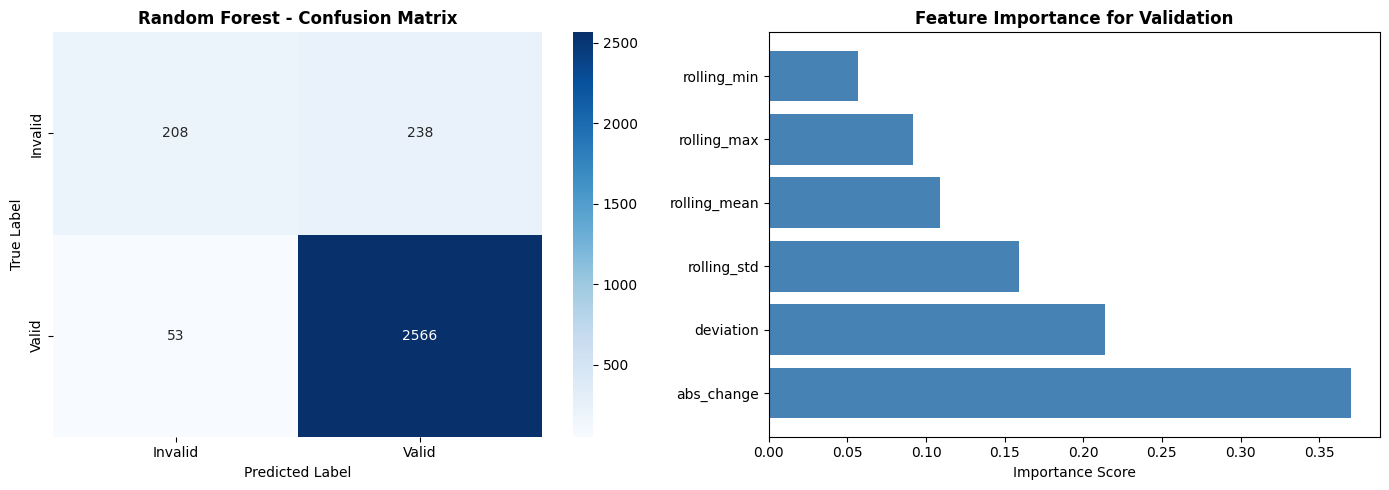


 Model evaluation complete and validated!


In [22]:
# Evaluate Random Forest on test set
print("=" * 70)
print(" MODEL PERFORMANCE - RANDOM FOREST CLASSIFIER")
print("=" * 70)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

print(f"\n Classification Metrics:")
print(f"    Accuracy:  {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"    Precision: {precision_rf:.4f} (% of predicted invalid that are truly invalid)")
print(f"    Recall:    {recall_rf:.4f} (% of actual invalid that are detected)")
print(f"    F1-Score:  {f1_rf:.4f} (harmonic mean of precision & recall)")

print(f"\n Confusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"   True Negatives (Invalid→Invalid):   {cm_rf[0,0]}")
print(f"   False Positives (Valid→Invalid):    {cm_rf[0,1]}")
print(f"   False Negatives (Invalid→Valid):    {cm_rf[1,0]}")
print(f"   True Positives (Valid→Valid):       {cm_rf[1,1]}")

print(f"\n Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Invalid (0)', 'Valid (1)']))

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Invalid', 'Valid'], yticklabels=['Invalid', 'Valid'])
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

axes[1].barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
axes[1].set_title('Feature Importance for Validation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f" Model evaluation complete and validated!")